# Keras CNN Image Model

This notebook trains the computer vision branch of the project.

The model receives only chart images. It does not receive claim text.

## Research purpose

The same chart image is connected to supported, refuted and
not-enough-information claims.

Because the text claim is hidden, the image-only model should not be
able to solve the complete verification task. This experiment measures
that limitation directly.

In [1]:
from pathlib import Path
import sys

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dataset_builder import (
    build_development_dataset,
)
from src.image_neural_network import (
    LABEL_ORDER,
    build_image_neural_network,
    create_image_dataset,
    decode_predictions,
    encode_labels,
)

keras.utils.set_random_seed(42)

In [2]:
processed_directory = (
    project_root
    / "data"
    / "processed"
)

train_data = pd.read_csv(
    processed_directory
    / "train_chart_claim_dataset.csv"
)

validation_data = pd.read_csv(
    processed_directory
    / "validation_chart_claim_dataset.csv"
)

print("Training rows:", len(train_data))
print(
    "Validation rows:",
    len(validation_data),
)

train_data[
    [
        "image_path",
        "chart_group_id",
        "label",
    ]
].head()

Training rows: 252
Validation rows: 54


,image_path,chart_group_id,label
0,data/generated/charts/development/window_2019_...,window_2019_2022,supported
1,data/generated/charts/development/window_2019_...,window_2019_2022,refuted
2,data/generated/charts/development/window_2019_...,window_2019_2022,not_enough_information
3,data/generated/charts/development/window_2019_...,window_2019_2022,supported
4,data/generated/charts/development/window_2019_...,window_2019_2022,refuted


## Recreate chart images when needed

Generated PNG files are ignored by Git, so this notebook rebuilds them
from the first real source series when they are missing.

In [3]:
first_image_path = (
    project_root
    / train_data["image_path"].iloc[0]
)

if not first_image_path.exists():
    source_data = pd.read_csv(
        processed_directory
        / "eu_unemployment_2019_2025.csv"
    )

    build_development_dataset(
        data=source_data,
        output_directory=(
            project_root
            / "data"
            / "generated"
            / "charts"
            / "development"
        ),
    )

print(
    "First image exists:",
    first_image_path.exists(),
)

First image exists: True


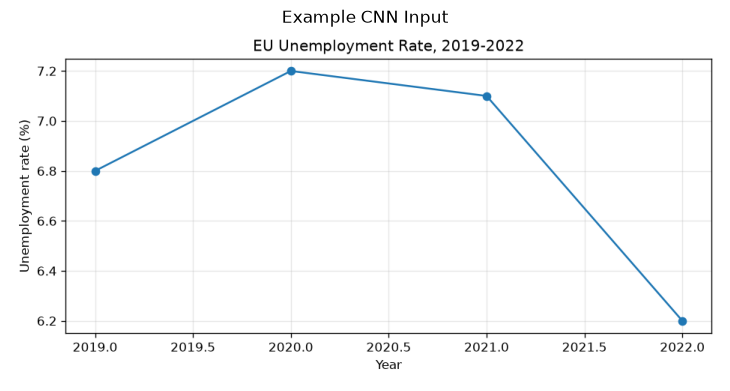

In [4]:
preview_image = plt.imread(
    first_image_path
)

plt.figure(figsize=(8, 4))
plt.imshow(preview_image)
plt.axis("off")
plt.title("Example CNN Input")
plt.tight_layout()
plt.show()

In [5]:
train_image_paths = [
    str(project_root / relative_path)
    for relative_path
    in train_data["image_path"]
]

validation_image_paths = [
    str(project_root / relative_path)
    for relative_path
    in validation_data["image_path"]
]

train_labels = encode_labels(
    train_data["label"]
)

validation_labels = encode_labels(
    validation_data["label"]
)

train_dataset = create_image_dataset(
    image_paths=train_image_paths,
    labels=train_labels,
    image_size=96,
    batch_size=16,
    shuffle=True,
    random_state=42,
)

validation_dataset = (
    create_image_dataset(
        image_paths=(
            validation_image_paths
        ),
        labels=validation_labels,
        image_size=96,
        batch_size=16,
        shuffle=False,
    )
)

## Build the convolutional neural network

In [6]:
image_model = (
    build_image_neural_network(
        image_size=96,
        dropout_rate=0.30,
        learning_rate=0.001,
    )
)

image_model.summary()

Model: "image_neural_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ chart_image (InputLayer)             │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pixel_rescaling (Rescaling)          │ (None, 96, 96, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_1 (Conv2D)                      │ (None, 96, 96, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool_1 (MaxPooling2D)                │ (None, 48, 48, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_2 (Conv2D)                      │ (None, 48, 48, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool_2 (MaxPooling2D)                │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_3 (Conv2D)                      │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling               │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ first_dropout (Dropout)              │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ hidden_dense (Dense)                 │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ second_dropout (Dropout)             │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ class_probabilities (Dense)          │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,763 (100.64 KB)

 Trainable params: 25,763 (100.64 KB)

 Non-trainable params: 0 (0.00 B)

## Training

Early stopping monitors validation loss and restores the best weights.

In [7]:
early_stopping = (
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
    )
)

history = image_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stopping],
    verbose=0,
)

print(
    "Epochs completed:",
    len(history.history["loss"]),
)

C:\Users\stana\Desktop\chart-claim-verification-bg\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epochs completed: 10


In [8]:
history_data = pd.DataFrame(
    history.history
)

history_data.index = (
    history_data.index + 1
)

history_data.index.name = "epoch"

history_data.tail()

,accuracy,loss,val_accuracy,val_loss
epoch,,,,
6,0.337302,1.099261,0.333333,1.098613
7,0.365079,1.097270,0.333333,1.098621
8,0.313492,1.099906,0.333333,1.098804
9,0.281746,1.100557,0.333333,1.098639
10,0.309524,1.099689,0.333333,1.098672


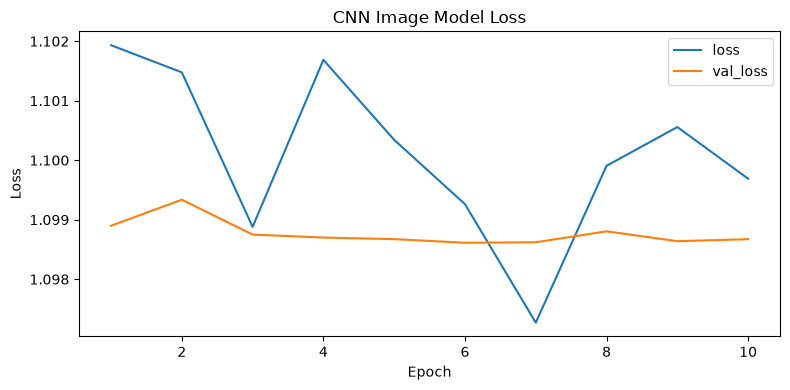

In [9]:
history_data[
    ["loss", "val_loss"]
].plot(
    figsize=(8, 4),
)

plt.title("CNN Image Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

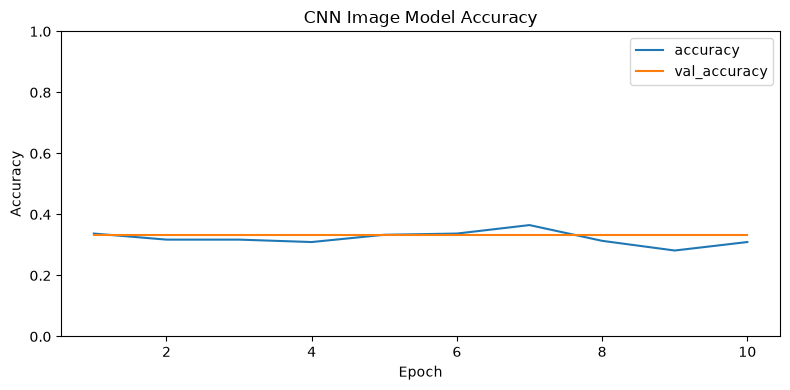

In [10]:
history_data[
    ["accuracy", "val_accuracy"]
].plot(
    figsize=(8, 4),
)

plt.title("CNN Image Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Validation evaluation

In [11]:
validation_probabilities = (
    image_model.predict(
        validation_dataset,
        verbose=0,
    )
)

validation_indices = np.argmax(
    validation_probabilities,
    axis=1,
)

validation_predictions = (
    decode_predictions(
        validation_indices
    )
)

validation_accuracy = (
    accuracy_score(
        validation_data["label"],
        validation_predictions,
    )
)

validation_macro_f1 = f1_score(
    validation_data["label"],
    validation_predictions,
    average="macro",
    zero_division=0,
)

image_neural_metrics = pd.DataFrame(
    [
        {
            "model": (
                "Keras CNN image model"
            ),
            "accuracy": (
                validation_accuracy
            ),
            "macro_f1": (
                validation_macro_f1
            ),
            "evaluation_split": (
                "validation"
            ),
        }
    ]
)

image_neural_metrics

,model,accuracy,macro_f1,evaluation_split
0,Keras CNN image model,0.333333,0.166667,validation


In [12]:
validation_report = pd.DataFrame(
    classification_report(
        validation_data["label"],
        validation_predictions,
        labels=LABEL_ORDER,
        output_dict=True,
        zero_division=0,
    )
).transpose()

validation_report

,precision,recall,f1-score,support
supported,0.333333,1.000000,0.500000,18.000000
refuted,0.000000,0.000000,0.000000,18.000000
not_enough_information,0.000000,0.000000,0.000000,18.000000
accuracy,0.333333,0.333333,0.333333,0.333333
macro avg,0.111111,0.333333,0.166667,54.000000
weighted avg,0.111111,0.333333,0.166667,54.000000


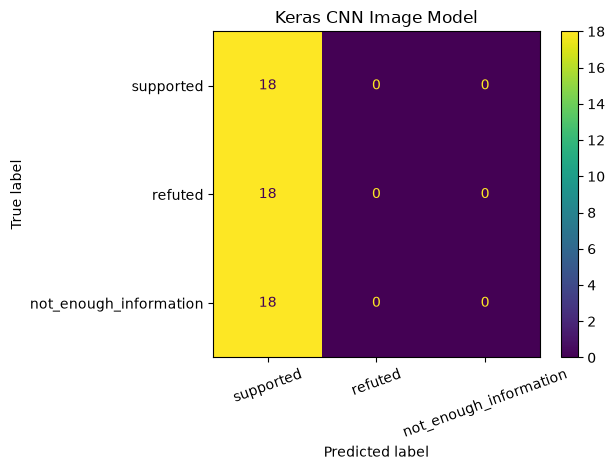

In [13]:
validation_matrix = (
    confusion_matrix(
        validation_data["label"],
        validation_predictions,
        labels=LABEL_ORDER,
    )
)

ConfusionMatrixDisplay(
    confusion_matrix=(
        validation_matrix
    ),
    display_labels=LABEL_ORDER,
).plot(
    xticks_rotation=20,
)

plt.title(
    "Keras CNN Image Model"
)
plt.tight_layout()
plt.show()

## Comparison with previous models

In [14]:
comparison_path = (
    project_root
    / "reports"
    / "model_validation_comparison.csv"
)

model_comparison = pd.read_csv(
    comparison_path
)

model_comparison = (
    model_comparison.loc[
        model_comparison["model"]
        != "Keras CNN image model"
    ]
)

model_comparison = pd.concat(
    [
        model_comparison,
        image_neural_metrics,
    ],
    ignore_index=True,
)

model_comparison

,model,accuracy,macro_f1,evaluation_split
0,Majority baseline,0.333333,0.166667,validation
1,TF-IDF + Logistic Regression,0.777778,0.772339,validation
2,Keras text neural network,0.833333,0.827894,validation
3,Keras CNN image model,0.333333,0.166667,validation


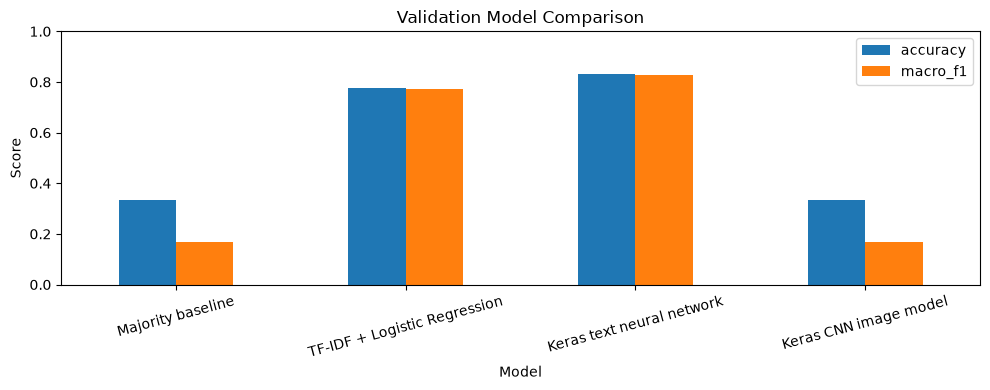

In [15]:
model_comparison.set_index(
    "model"
)[
    ["accuracy", "macro_f1"]
].plot(
    kind="bar",
    figsize=(10, 4),
)

plt.title(
    "Validation Model Comparison"
)
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Save results

The trained model remains local because `.keras` files are ignored by
Git.

In [16]:
reports_directory = (
    project_root / "reports"
)

models_directory = (
    project_root / "models"
)

reports_directory.mkdir(
    parents=True,
    exist_ok=True,
)

models_directory.mkdir(
    parents=True,
    exist_ok=True,
)

history_data.to_csv(
    reports_directory
    / "image_neural_network_history.csv"
)

image_neural_metrics.to_csv(
    reports_directory
    / (
        "image_neural_network_"
        "validation_metrics.csv"
    ),
    index=False,
)

validation_report.to_csv(
    reports_directory
    / (
        "image_neural_network_"
        "validation_report.csv"
    )
)

pd.DataFrame(
    validation_matrix,
    index=[
        f"actual_{label}"
        for label in LABEL_ORDER
    ],
    columns=[
        f"predicted_{label}"
        for label in LABEL_ORDER
    ],
).to_csv(
    reports_directory
    / (
        "image_neural_network_"
        "validation_confusion_matrix.csv"
    )
)

model_comparison.to_csv(
    reports_directory
    / "model_validation_comparison.csv",
    index=False,
)

image_model.save(
    models_directory
    / "image_neural_network.keras"
)

print("Image model and reports saved.")

Image model and reports saved.


## Result

An image-only score near the majority baseline is expected because the
same chart image is paired with all three claim labels.

This does not mean that the CNN failed to process images. It means that
the verification label depends on both the chart and the claim text.

The test split remains untouched.